In [16]:
# 参考： https://cloud.tencent.com.cn/developer/article/2324819
import torch
from torch import nn
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
NUM_EPOCHS = 100
model = nn.Linear(2,1)

def schedular_lr(optimizer, schedular):
    lr_history = []
    epoch_history = []
    """optimizer的更新在scheduler更新的前面"""
    for epoch in range(NUM_EPOCHS):
        optimizer.step() # 更新参数
        lr_history.append(optimizer.param_groups[0]['lr'])
        schedular.step() # 调整学习率
    plt.plot(lr_history)
    return lr_history

torch.optim版本:

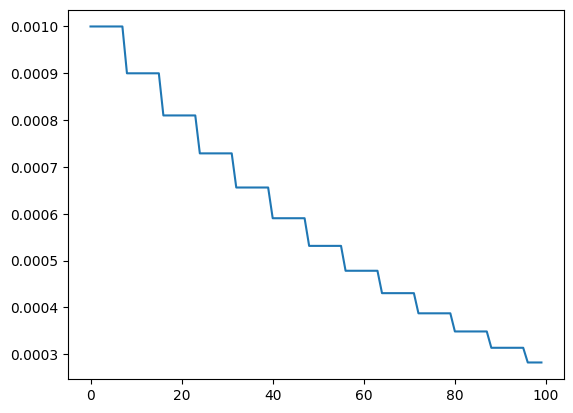

In [17]:
# 设置优化器，初始化学习率
optimizer = torch.optim.SGD(model.parameters(),lr=1e-3)
# 设置学习率调整策略
schedular = StepLR(optimizer=optimizer,step_size=8,gamma=0.9)
lr_his = schedular_lr(optimizer, schedular)


#### 自定义版本

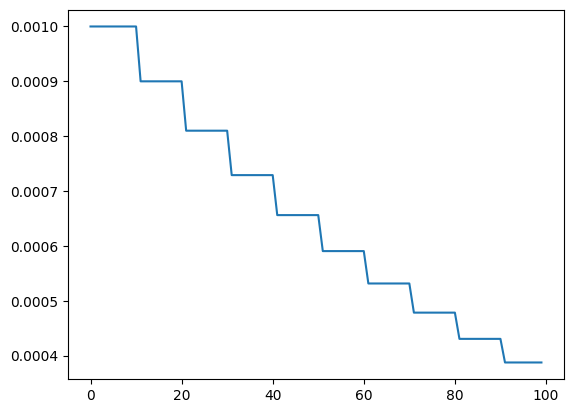

In [18]:
class CustomStepLR:
    def __init__(self, optimizer,step_size,gamma=0.9,last_epoch=-1):
        self.optimizer = optimizer
        self.step_size = step_size
        self.gamma = gamma
        self.last_epoch = last_epoch
        
    def get_lr(self):
        if (self.last_epoch==0) or (self.last_epoch%self.step_size!=0): # 只是获取当前的lr
            return [group['lr'] for group in self.optimizer.param_groups]
        return [group['lr'] * self.gamma for group in self.optimizer.param_groups]

    def step(self):
        self.last_epoch += 1
        lrs = self.get_lr()
        for param, lr in zip(self.optimizer.param_groups,lrs):
            param['lr'] = lr
        
optimizer2 = torch.optim.SGD(model.parameters(),lr=1e-3)
scheduler2 = CustomStepLR(optimizer2,step_size=10)
lr_his = schedular_lr(optimizer2, scheduler2)

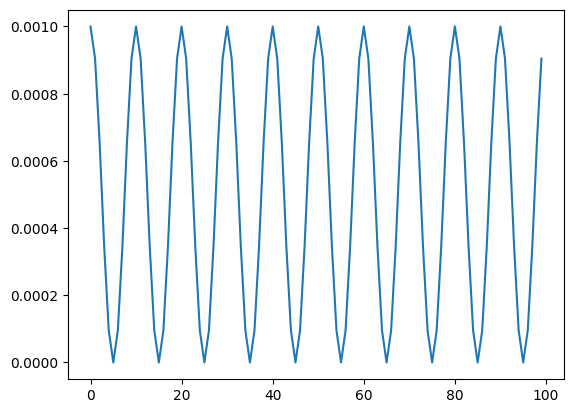

In [19]:
# 设置优化器，初始化学习率
optimizer = torch.optim.SGD(model.parameters(),lr=1e-3)
# 设置学习率调整策略
schedular = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max=5)
lr_his = schedular_lr(optimizer, schedular)

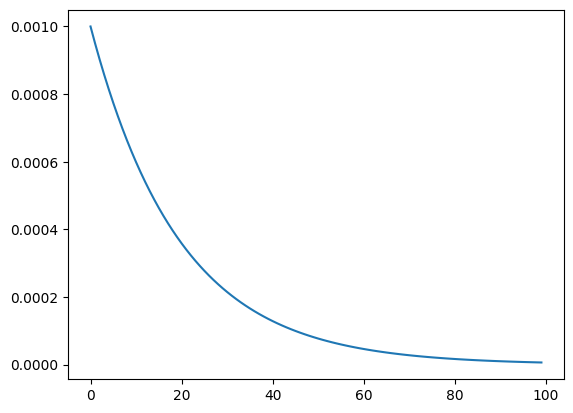

In [20]:
# 设置优化器，初始化学习率
optimizer = torch.optim.SGD(model.parameters(),lr=1e-3)
# 设置学习率调整策略
schedular = torch.optim.lr_scheduler.ExponentialLR(optimizer=optimizer, gamma=0.95)
lr_his = schedular_lr(optimizer, schedular)

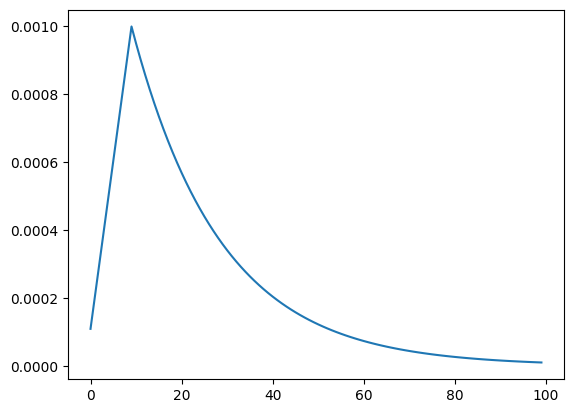

In [25]:
## -------------------------------- 结合warmup strategy --------------------------------

class WarmupScheduler:
    def __init__(self, optimizer, warmup_steps, initial_lr, target_lr):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.initial_lr = initial_lr
        self.target_lr = target_lr
        self.step_count = 0

    def step(self):
        self.step_count += 1
        if self.step_count <= self.warmup_steps:
            lr = self.initial_lr + (self.target_lr - self.initial_lr) * (self.step_count / self.warmup_steps)
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr

    def get_last_lr(self):
        return [param_group['lr'] for param_group in self.optimizer.param_groups]


def schedular_lr_new(optimizer, schedular1, schedular2, NUM_EPOCHS=100):
    lr_history = []
    epoch_history = []
    """optimizer的更新在scheduler更新的前面"""
    for epoch in range(NUM_EPOCHS):
        if epoch < warmup_steps:
            schedular2.step() # 调整学习率
        
        optimizer.step() # 更新参数(根据当前的学习率lr==》做参数更新)
        # lr_history.append(optimizer.param_groups[0]['lr'])   # 如果在这里获取学习率，则warmup_scheduler的step()会先于optimizer.step()执行
        # TODO: warmup_scheduler的step()会先于optimizer.step()执行

        if epoch >= warmup_steps:
            schedular1.step() # 调整学习率
            
        lr_history.append(optimizer.param_groups[0]['lr'])
    plt.plot(lr_history)
    return lr_history


# num_epochs = 100
warmup_steps = 10  # Warmup 的步数
initial_lr = 0.00001  # 初始学习率
target_lr = 0.001  # 目标学习率


# 设置优化器，初始化学习率
optimizer = torch.optim.SGD(model.parameters(),lr=1e-3)

warmup_scheduler = WarmupScheduler(optimizer, warmup_steps, initial_lr, target_lr)
# 设置学习率调整策略
schedular = torch.optim.lr_scheduler.ExponentialLR(optimizer=optimizer, gamma=0.95)
lr_his = schedular_lr_new(optimizer, schedular,warmup_scheduler)

In [22]:
lr_his

[0.00019,
 0.00028000000000000003,
 0.00037,
 0.00046,
 0.00055,
 0.00064,
 0.00073,
 0.0008200000000000001,
 0.00091,
 0.001,
 0.00095,
 0.0009025,
 0.000857375,
 0.0008145062499999999,
 0.0007737809374999998,
 0.0007350918906249997,
 0.0006983372960937497,
 0.0006634204312890621,
 0.000630249409724609,
 0.0005987369392383785,
 0.0005688000922764595,
 0.0005403600876626365,
 0.0005133420832795047,
 0.00048767497911552944,
 0.00046329123015975297,
 0.0004401266686517653,
 0.00041812033521917703,
 0.00039721431845821814,
 0.0003773536025353072,
 0.0003584859224085418,
 0.0003405616262881147,
 0.00032353354497370894,
 0.00030735686772502346,
 0.00029198902433877225,
 0.00027738957312183364,
 0.0002635200944657419,
 0.0002503440897424548,
 0.00023782688525533205,
 0.00022593554099256544,
 0.00021463876394293716,
 0.0002039068257457903,
 0.00019371148445850077,
 0.00018402591023557573,
 0.00017482461472379692,
 0.00016608338398760707,
 0.0001577792147882267,
 0.00014989025404881537,
 0.000

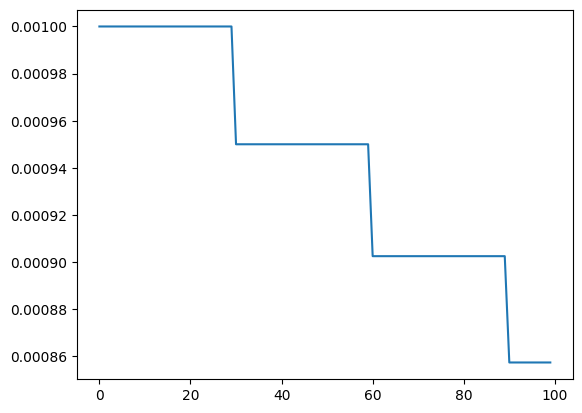

In [23]:
# 设置优化器，初始化学习率
optimizer = torch.optim.SGD(model.parameters(),lr=1e-3)
# 设置学习率调整策略 scheduler = MultiStepLR(optimizer, milestones=[30, 60, 90], gamma=0.1)
schedular = torch.optim.lr_scheduler.MultiStepLR(optimizer=optimizer, milestones=[30, 60, 90], gamma=0.95)
lr_his = schedular_lr(optimizer, schedular)